# Visual laboratory: one vector, two bases

A vector is the underlying object. Coordinates are scalar instructions relative to an ordered basis. We represent the same $\vec v=(3,2)$ using the standard basis and the skew basis $\mathcal B=((1,0),(1,1))$.

## Standard and skew coordinates

$$
[\vec v]_{\mathcal E}=\begin{bmatrix}3\\2\end{bmatrix},
\qquad
[\vec v]_{\mathcal B}=\begin{bmatrix}1\\2\end{bmatrix}.
$$

Both coordinate lists reconstruct the same endpoint.

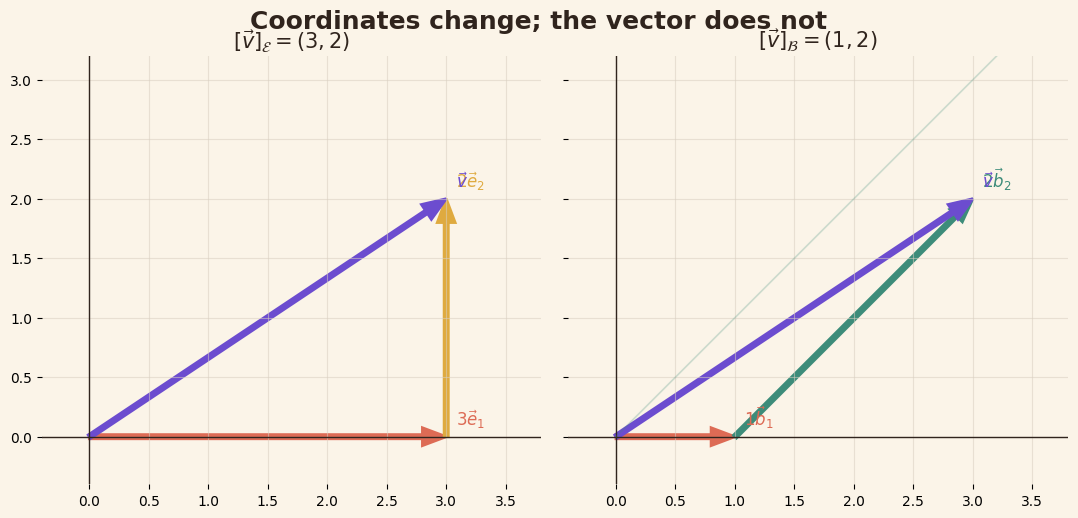

In [1]:
import numpy as np
import matplotlib.pyplot as plt

paper='#fbf4e8'; ink='#30241d'; purple='#6c4ccf'; coral='#dd6b55'; teal='#3d8c7a'; gold='#dfaa3f'; grid='#d9cfc1'
v=np.array([3.,2.]); e1=np.array([1.,0.]); e2=np.array([0.,1.]); b1=np.array([1.,0.]); b2=np.array([1.,1.])

def arrow(ax, origin, vec, color, label, width=.035):
    ax.arrow(*origin, *vec, length_includes_head=True, head_width=.15, head_length=.2, linewidth=2, width=width, color=color)
    p=np.asarray(origin)+np.asarray(vec); ax.text(p[0]+.08,p[1]+.1,label,color=color,fontsize=12,weight='bold')

fig, axes=plt.subplots(1,2,figsize=(11,5),facecolor=paper,sharex=True,sharey=True)
for ax in axes:
    ax.set_facecolor(paper); ax.axhline(0,color=ink,lw=1); ax.axvline(0,color=ink,lw=1); ax.grid(color=grid,alpha=.55); ax.set_aspect('equal')
    ax.set_xlim(-.4,3.8); ax.set_ylim(-.4,3.2)
    for s in ax.spines.values(): s.set_visible(False)
arrow(axes[0],(0,0),3*e1,coral,r'$3\vec e_1$')
arrow(axes[0],3*e1,2*e2,gold,r'$2\vec e_2$')
arrow(axes[0],(0,0),v,purple,r'$\vec v$')
axes[0].set_title(r'$[\vec v]_{\mathcal{E}}=(3,2)$',color=ink,fontsize=15,weight='bold')
arrow(axes[1],(0,0),b1,coral,r'$1\vec b_1$')
arrow(axes[1],b1,2*b2,teal,r'$2\vec b_2$')
arrow(axes[1],(0,0),v,purple,r'$\vec v$')
axes[1].plot([0,4], [0,4], color=teal, alpha=.25, lw=1.2)
axes[1].set_title(r'$[\vec v]_{\mathcal{B}}=(1,2)$',color=ink,fontsize=15,weight='bold')
fig.suptitle('Coordinates change; the vector does not',color=ink,fontsize=18,weight='bold')
fig.tight_layout(); plt.show()

## The basis matrix reconstructs world coordinates

Placing the skew basis vectors as columns gives

$$
B=\begin{bmatrix}1&1\\0&1\end{bmatrix},
\qquad
\vec v=B[\vec v]_{\mathcal B}.
$$

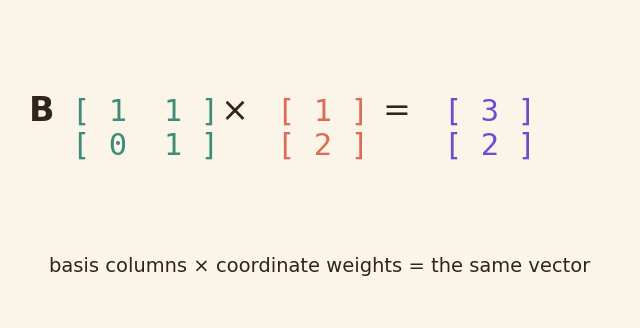

In [2]:
B=np.column_stack([b1,b2])
coords=np.array([1.,2.])
world=B@coords
fig, ax=plt.subplots(figsize=(8,4),facecolor=paper); ax.set_facecolor(paper); ax.axis('off')
ax.text(.03,.64,'B',fontsize=24,color=ink,weight='bold',transform=ax.transAxes)
ax.text(.10,.53,'[ 1  1 ]\n[ 0  1 ]',fontsize=22,color=teal,fontfamily='monospace',transform=ax.transAxes)
ax.text(.34,.64,'×',fontsize=24,color=ink,transform=ax.transAxes)
ax.text(.43,.53,'[ 1 ]\n[ 2 ]',fontsize=22,color=coral,fontfamily='monospace',transform=ax.transAxes)
ax.text(.60,.64,'=',fontsize=24,color=ink,transform=ax.transAxes)
ax.text(.70,.53,'[ 3 ]\n[ 2 ]',fontsize=22,color=purple,fontfamily='monospace',transform=ax.transAxes)
ax.text(.5,.15,'basis columns × coordinate weights = the same vector',fontsize=14,color=ink,ha='center',transform=ax.transAxes)
plt.show()